# LEGO Rebrickable EDA + NLP (Colab skeleton)

## 1. Setup & imports

# LEGO + Movies + World Facts EDA & NLP (Colab)

Exploratory data analysis and lightweight NLP across:
- Rebrickable LEGO starter files
- The Movies Dataset (Kaggle)
- World Factbook by CIA (Kaggle)

In [1]:
# 1. Setup & imports
%pip install -q pandas matplotlib seaborn plotly scikit-learn textblob nltk



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob
import nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 2. Load data from GitHub

Adapt the `base_url` below if you upload files manually to Colab.

In [ ]:
import io
import zipfile
import requests
import pandas as pd

zip_url = (
    "https://github.com/shannonlindsay/FabricCommunityContests/"
    "raw/main/StarterFiles/Round%202%20Source%20Files.zip"
)

# 1. Download ZIP into memory
resp = requests.get(zip_url)
resp.raise_for_status()

# 2. Open ZIP
zip_bytes = io.BytesIO(resp.content)
z = zipfile.ZipFile(zip_bytes)


['World Champs Round 2 Data/', 'World Champs Round 2 Data/colors.csv', 'World Champs Round 2 Data/inventories.csv', 'World Champs Round 2 Data/inventory_minifigs.csv', 'World Champs Round 2 Data/inventory_parts.csv', 'World Champs Round 2 Data/inventory_sets.csv', 'World Champs Round 2 Data/minifigs.csv', 'World Champs Round 2 Data/parts.csv', 'World Champs Round 2 Data/part_categories.csv', 'World Champs Round 2 Data/Rebrickable.url', 'World Champs Round 2 Data/sets.csv', 'World Champs Round 2 Data/themes.csv']


KeyError: "There is no item named 'sets.csv' in the archive"

In [ ]:

# save zip
# 3. List files inside the ZIP
print(z.namelist())


In [ ]:
zip_file_path = '/content/your_dataset.zip' 

with zipfile.ZipFile(zip_file_path, 'r') as zf:
    csv_files = [f for f in zf.namelist() if f.endswith('.csv')]
    print(csv_files)

AttributeError: 'ZipFile' object has no attribute 'seek'

In [6]:
def read_csv_from_zip(zip_file, inner_path):
    with zip_file.open(inner_path) as f:
        return pd.read_csv(f)

dfs = {}

dfs["colors"] = read_csv_from_zip(z, "World Champs Round 2 Data/colors.csv")
dfs["inventories"] = read_csv_from_zip(z, "World Champs Round 2 Data/inventories.csv")
dfs["inventory_minifigs"] = read_csv_from_zip(z, "World Champs Round 2 Data/inventory_minifigs.csv")
dfs["inventory_parts"] = read_csv_from_zip(z, "World Champs Round 2 Data/inventory_parts.csv")
dfs["inventory_sets"] = read_csv_from_zip(z, "World Champs Round 2 Data/inventory_sets.csv")
dfs["minifigs"] = read_csv_from_zip(z, "World Champs Round 2 Data/minifigs.csv")
dfs["parts"] = read_csv_from_zip(z, "World Champs Round 2 Data/parts.csv")
dfs["part_categories"] = read_csv_from_zip(z, "World Champs Round 2 Data/part_categories.csv")
dfs["sets"] = read_csv_from_zip(z, "World Champs Round 2 Data/sets.csv")
dfs["themes"] = read_csv_from_zip(z, "World Champs Round 2 Data/themes.csv")

for name, df in dfs.items():
    print(f"{name}: {df.shape}")


colors: (275, 8)
inventories: (45944, 3)
inventory_minifigs: (25448, 3)
inventory_parts: (1524178, 6)
inventory_sets: (5046, 3)
minifigs: (16960, 4)
parts: (63345, 4)
part_categories: (76, 2)
sets: (27069, 6)
themes: (494, 3)


## 3. Data dictionary style overview

In [7]:
for name, df in dfs.items():
    print(f"\n=== {name} ===")
    print(df.head())
    print(df.info())


=== colors ===
   id            name     rgb  is_trans  num_parts  num_sets      y1      y2
0  -1       [Unknown]  0033B2     False         17         2  2000.0  2000.0
1   0           Black  05131D     False     823845    228939  1957.0  2026.0
2   1            Blue  0055BF     False     205371     49738  1949.0  2026.0
3   2           Green  237841     False      90081     26681  1949.0  2026.0
4   3  Dark Turquoise  008F9B     False      23373      6269  1998.0  2026.0
<class 'pandas.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         275 non-null    int64  
 1   name       275 non-null    str    
 2   rgb        275 non-null    str    
 3   is_trans   275 non-null    bool   
 4   num_parts  275 non-null    int64  
 5   num_sets   275 non-null    int64  
 6   y1         273 non-null    float64
 7   y2         273 non-null    float64
dtypes: bool(1), float64(2), 

## 4. Basic EDA on sets and themes

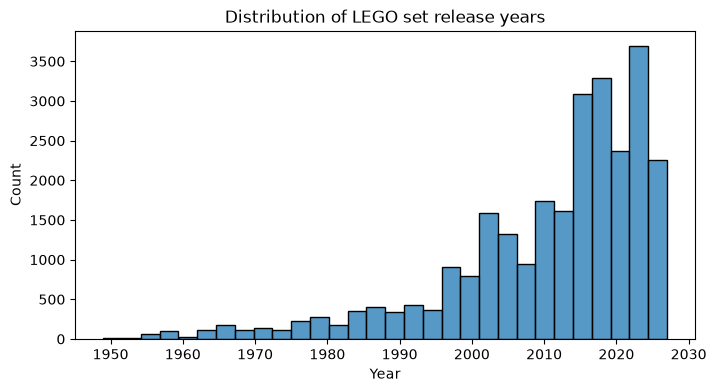

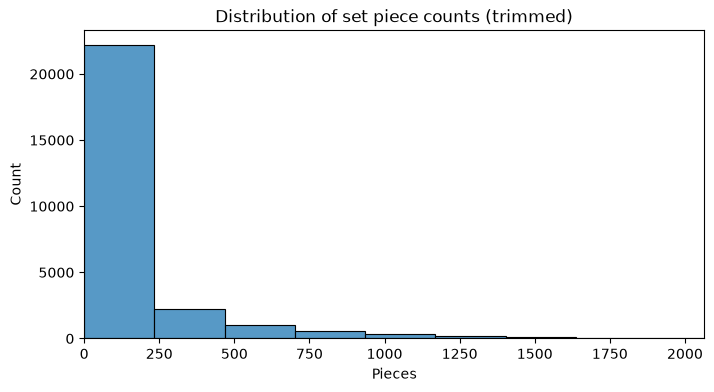

In [8]:
sets = dfs["sets"]
themes = dfs["themes"]

# join themes onto sets (adjust column names if needed)
sets_themes = sets.merge(
    themes,
    left_on="theme_id",
    right_on="id",
    suffixes=("_set", "_theme")
)

# distribution of release year
plt.figure(figsize=(8, 4))
sns.histplot(sets["year"], bins=30, kde=False)
plt.title("Distribution of LEGO set release years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# distribution of num_parts (trim 99th percentile to avoid crazy tails)
plt.figure(figsize=(8, 4))
sns.histplot(sets["num_parts"], bins=50, kde=False)
plt.xlim(0, sets["num_parts"].quantile(0.99))
plt.title("Distribution of set piece counts (trimmed)")
plt.xlabel("Pieces")
plt.ylabel("Count")
plt.show()

# average pieces per year
avg_pieces_year = (
    sets.groupby("year")["num_parts"]
    .mean()
    .reset_index()
    .rename(columns={"num_parts": "avg_num_parts"})
)

fig = px.line(
    avg_pieces_year,
    x="year",
    y="avg_num_parts",
    title="Average pieces per set over time"
)
fig.show()

## 5. Color analysis

In [9]:
colors = dfs["colors"]
print("\nColors preview:")
print(colors.head())

# count how many distinct colors exist
print(f"Number of colors: {colors.shape[0]}")


Colors preview:
   id            name     rgb  is_trans  num_parts  num_sets      y1      y2
0  -1       [Unknown]  0033B2     False         17         2  2000.0  2000.0
1   0           Black  05131D     False     823845    228939  1957.0  2026.0
2   1            Blue  0055BF     False     205371     49738  1949.0  2026.0
3   2           Green  237841     False      90081     26681  1949.0  2026.0
4   3  Dark Turquoise  008F9B     False      23373      6269  1998.0  2026.0
Number of colors: 275


## 6. Minifig analysis

In [10]:
minifigs = dfs["minifigs"]
inv_minifigs = dfs["inventory_minifigs"]

print("\nMinifigs preview:")
print(minifigs.head())
print(inv_minifigs.head())


Minifigs preview:
      fig_num                                      name  num_parts  \
0  fig-000001                        Toy Store Employee          4   
1  fig-000002                              Customer Kid          4   
2  fig-000003                     Assassin Droid, White          8   
3  fig-000004  Man, White Torso, Black Legs, Brown Hair          4   
4  fig-000005           Captain America with Short Legs          3   

                                             img_url  
0  https://cdn.rebrickable.com/media/sets/fig-000...  
1  https://cdn.rebrickable.com/media/sets/fig-000...  
2  https://cdn.rebrickable.com/media/sets/fig-000...  
3  https://cdn.rebrickable.com/media/sets/fig-000...  
4  https://cdn.rebrickable.com/media/sets/fig-000...  
   inventory_id     fig_num  quantity
0             3  fig-001549         1
1             4  fig-000764         1
2            19  fig-000555         1
3            25  fig-000574         1
4            26  fig-000842         1


## 7. Lightweight NLP on text fields

In [12]:
import nltk
nltk.download("punkt")
print(nltk.data.path)

['/home/codespace/nltk_data', '/usr/local/python/3.12.1/nltk_data', '/usr/local/python/3.12.1/share/nltk_data', '/usr/local/python/3.12.1/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']


[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [15]:
import os
import nltk

nltk_data_dir = os.path.join(os.getcwd(), "nltk_data")
os.makedirs(nltk_data_dir, exist_ok=True)

nltk.data.path.append(nltk_data_dir)
nltk.download("punkt", download_dir=nltk_data_dir)
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /workspaces/lego-
[nltk_data]     data/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [16]:
from nltk import word_tokenize

text_cols = {
    "sets": ["name"],
    "themes": ["name"],
    "parts": ["name"],
    "minifigs": ["name"]
}

for tbl, cols in text_cols.items():
    df = dfs[tbl].copy()
    for col in cols:
        df[col] = df[col].astype(str)

        df["tok_count"] = df[col].apply(lambda x: len(word_tokenize(x)))
        print(f"\nNLP stats for {tbl}.{col}")
        print(df["tok_count"].describe())

        keywords = ["football", "soccer", "stadium", "goal", "world cup"]
        mask = df[col].str.lower().str.contains("|".join(keywords))

        print(f"Found {mask.sum()} {tbl} rows mentioning soccer/football keywords")
        print(df.loc[mask, [col]].head(20))


NLP stats for sets.name
count    27069.000000
mean         3.891204
std          2.386113
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         23.000000
Name: tok_count, dtype: float64
Found 73 sets rows mentioning soccer/football keywords
                                                  name
486            Real Madrid – Santiago Bernabéu Stadium
1806                   Small Soccer Set 1 (Kabaya Box)
1807                      Small Soccer Set 1 (Polybag)
1808                   Small Soccer Set 2 (Kabaya Box)
1809                      Small Soccer Set 2 (Polybag)
1811                   Small Soccer Set 3 (Kabaya Box)
1812                      Small Soccer Set 3 (Polybag)
1949                                      Football Pen
3290                                    Table Football
4193  Santa Claus Mos Burger Gift Box 3 - Soccer Santa
5436                                      Soccer Field
5445                                    Soccer Goali

## 8. Simple sentiment on set names (illustrative)


Sample sentiment on set names:
                          name  sentiment
0  Ninjago: Book of Adventures        0.0
1                        Gears        0.0
2            Town Mini-Figures        0.0
3   Castle 2 for 1 Bonus Offer        0.0
4           Space Mini-Figures        0.0


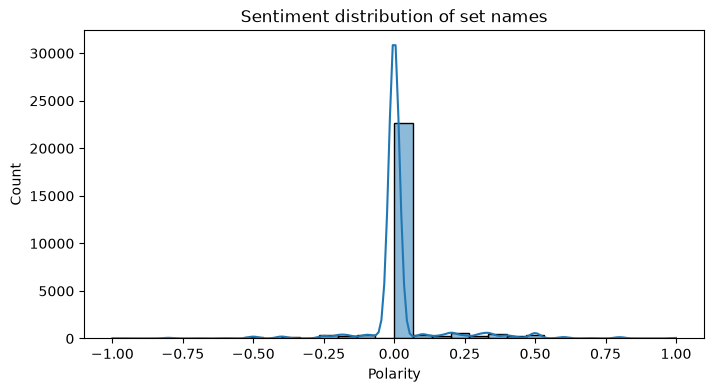

In [17]:
sets["name"] = sets["name"].astype(str)
sets["sentiment"] = sets["name"].apply(lambda x: TextBlob(x).sentiment.polarity)

print("\nSample sentiment on set names:")
print(sets[["name", "sentiment"]].head())

plt.figure(figsize=(8, 4))
sns.histplot(sets["sentiment"], bins=30, kde=True)
plt.title("Sentiment distribution of set names")
plt.xlabel("Polarity")
plt.ylabel("Count")
plt.show()

## 9. Export summary tables

Export summary tables for later use (e.g., Power BI, Fabric).

In [ ]:
avg_pieces_year.to_csv("avg_pieces_year.csv", index=False)

In [18]:
colors = dfs["colors"].copy()

# Basic derived metrics
colors["lifetime_years"] = colors["y2"] - colors["y1"]
colors["avg_parts_per_set"] = colors["num_parts"] / colors["num_sets"]

color_lifetime = colors[
    ["id", "name", "is_trans", "num_parts", "num_sets", "y1", "y2",
     "lifetime_years", "avg_parts_per_set"]
].sort_values("lifetime_years", ascending=False)

print(color_lifetime.head(10))

       id                  name  is_trans  num_parts  num_sets      y1  \
3       2                 Green     False      90081     26681  1949.0   
2       1                  Blue     False     205371     49738  1949.0   
11     10          Bright Green     False      27550      8390  1949.0   
16     15                 White     False     514086    150469  1949.0   
15     14                Yellow     False     213892     71600  1949.0   
5       4                   Red     False     317761     95198  1949.0   
42     47           Trans-Clear      True      47022     15266  1954.0   
274  9999  [No Color/Any Color]     False      10607     10361  1955.0   
1       0                 Black     False     823845    228939  1957.0   
261  1135                 Metal     False         56        31  1957.0   

         y2  lifetime_years  avg_parts_per_set  
3    2026.0            77.0           3.376223  
2    2026.0            77.0           4.129056  
11   2026.0            77.0           

In [19]:
color_lifetime.to_csv("color_lifetime_summary.csv", index=False)

In [21]:
inv_parts = dfs["inventory_parts"]
inventories = dfs["inventories"]
sets = dfs["sets"]
themes = dfs["themes"]
colors = dfs["colors"]

# inventory_parts -> inventories (to get set_num)
inv_parts_sets = inv_parts.merge(
    inventories[["id", "set_num"]],
    left_on="inventory_id",
    right_on="id",
    suffixes=("", "_inv")
)

# add set metadata
inv_parts_sets = inv_parts_sets.merge(
    sets[["set_num", "year", "theme_id"]],
    on="set_num",
    how="left"
)

# add theme and color names
inv_parts_sets = inv_parts_sets.merge(
    themes[["id", "name"]],
    left_on="theme_id",
    right_on="id",
    how="left",
    suffixes=("", "_theme")
)

inv_parts_sets = inv_parts_sets.merge(
    colors[["id", "name"]],
    left_on="color_id",
    right_on="id",
    how="left",
    suffixes=("", "_color")
)



In [ ]:
# Now you have: part_num, color_id, name_color,, year, quantity, etc.
print(inv_parts_sets[["part_num", "name_color", "year"]].head())

         part_num            name_color    year
0        48379c04      Dark Bluish Gray  2004.0
1           48391                 Black  2004.0
2           48395            Light Gray  2004.0
3        48864c01                Orange  2004.0
4  stickerupn0077  [No Color/Any Color]  2004.0


In [27]:
inv_parts = dfs["inventory_parts"]
inventories = dfs["inventories"]
sets = dfs["sets"]
themes = dfs["themes"]
colors = dfs["colors"]

# inventory_parts -> inventories (to get set_num)
inv_parts_sets = inv_parts.merge(
    inventories[["id", "set_num"]],
    left_on="inventory_id",
    right_on="id",
    suffixes=("", "_inv")
)

# add set metadata
inv_parts_sets = inv_parts_sets.merge(
    sets[["set_num", "year", "theme_id"]],
    on="set_num",
    how="left"
)

# add theme and color names
inv_parts_sets = inv_parts_sets.merge(
    themes[["id", "name"]],
    left_on="theme_id",
    right_on="id",
    how="left",
    suffixes=("", "_theme")
)

inv_parts_sets = inv_parts_sets.merge(
    colors[["id", "name"]],
    left_on="color_id",
    right_on="id",
    how="left",
    suffixes=("", "_color")
)

print(inv_parts_sets)
print(themes)
# Now you have: part_num, color_id, name_color, theme_name, year, quantity, etc.
print(inv_parts_sets[["part_num", "name_color", "name", "year"]].head())

         inventory_id         part_num  color_id  quantity  is_spare  \
0                   1         48379c04        72         1     False   
1                   1            48391         0         1     False   
2                   1            48395         7         1     False   
3                   1         48864c01        25         1     False   
4                   1   stickerupn0077      9999         1     False   
...               ...              ...       ...       ...       ...   
1524173        341157             2446      1062         1     False   
1524174        341157      28621pr4230        14         1     False   
1524175        341157            41805        47         1     False   
1524176        341157     970c03pr0408         0         1     False   
1524177        341157  973c03h12pr5419         0         1     False   

                                                   img_url      id  \
0        https://cdn.rebrickable.com/media/parts/photos...       

In [28]:
theme_color_usage = (
    inv_parts_sets
    .groupby(["name", "name_color"], dropna=False)["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"name": "theme", "name_color": "color", "quantity": "total_quantity"})
)

print(theme_color_usage.head(20))
theme_color_usage.to_csv("theme_color_usage.csv", index=False)

        theme                 color  total_quantity
0         12V                 Black            3628
1         12V                  Blue             582
2         12V                 Brown               6
3         12V             Dark Gray             449
4         12V                 Green               1
5         12V            Light Gray            2080
6         12V                 Metal               5
7         12V           Milky White               4
8         12V                   Red            1734
9         12V           Trans-Clear             348
10        12V             Trans-Red              58
11        12V          Trans-Yellow              30
12        12V                 White             523
13        12V                Yellow             791
14        12V  [No Color/Any Color]              28
15  4 Juniors                 Black             235
16  4 Juniors                  Blue              28
17  4 Juniors           Chrome Gold              12
18  4 Junior

In [29]:
color_year_usage = (
    inv_parts_sets
    .groupby(["year", "name_color"], dropna=False)["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"name_color": "color", "quantity": "total_quantity"})
)

print(color_year_usage.head())
color_year_usage.to_csv("color_year_usage.csv", index=False)

     year         color  total_quantity
0  1949.0          Blue              72
1  1949.0  Bright Green               6
2  1949.0         Green             140
3  1949.0           Red             151
4  1949.0  Vintage Blue              24


In [30]:
year_totals = (
    color_year_usage
    .groupby("year")["total_quantity"]
    .sum()
    .reset_index()
    .rename(columns={"total_quantity": "year_total"})
)

color_year_share = color_year_usage.merge(year_totals, on="year")
color_year_share["share"] = (
    color_year_share["total_quantity"] / color_year_share["year_total"]
)

print(color_year_share.head())
color_year_share.to_csv("color_year_share.csv", index=False)

     year         color  total_quantity  year_total     share
0  1949.0          Blue              72         790  0.091139
1  1949.0  Bright Green               6         790  0.007595
2  1949.0         Green             140         790  0.177215
3  1949.0           Red             151         790  0.191139
4  1949.0  Vintage Blue              24         790  0.030380


In [32]:
# quick manual grouping example
warm_keywords = ["Red", "Orange", "Yellow"]
cool_keywords = ["Blue", "Green", "Turquoise"]
neon_keywords = ["Neon", "Bright", "Vibrant"]
black_keywords = ["Black"]
white_keywords = ["White"]
greyscale_keywords = ["Grey", "Gray", "Silver"]

def classify_color(name: str) -> str:
    if any(k.lower() in name.lower() for k in warm_keywords):
        return "Warm"
    if any(k.lower() in name.lower() for k in cool_keywords):
        return "Cool"
    if any(k.lower() in name.lower() for k in neon_keywords):
        return "Neon/Fantasy"
    return "Other"

colors["palette_group"] = colors["name"].apply(classify_color)
print(colors[["name", "palette_group"]].head())

             name palette_group
0       [Unknown]         Other
1           Black         Other
2            Blue          Cool
3           Green          Cool
4  Dark Turquoise          Cool


In [33]:
inv_minifigs = dfs["inventory_minifigs"]
minifigs = dfs["minifigs"]

# link minifigs to inventories → inventory_parts
minifig_inv_parts = (
    inv_minifigs[["inventory_id", "fig_num"]]
    .merge(inv_parts[["inventory_id", "color_id"]], on="inventory_id")
    .merge(colors[["id", "name"]], left_on="color_id", right_on="id")
)

# distinct colors per minifig
minifig_color_counts = (
    minifig_inv_parts
    .groupby("fig_num")["name"]
    .nunique()
    .reset_index()
    .rename(columns={"name": "num_distinct_colors"})
)

# add minifig metadata
minifig_color_counts = minifig_color_counts.merge(
    minifigs[["fig_num", "name", "num_parts"]],
    on="fig_num"
)

print(minifig_color_counts.head())
minifig_color_counts.to_csv("minifig_color_richness.csv", index=False)

      fig_num  num_distinct_colors                                      name  \
0  fig-000001                   24                        Toy Store Employee   
1  fig-000002                   24                              Customer Kid   
2  fig-000003                   23                     Assassin Droid, White   
3  fig-000004                   13  Man, White Torso, Black Legs, Brown Hair   
4  fig-000005                   17           Captain America with Short Legs   

   num_parts  
0          4  
1          4  
2          8  
3          4  
4          3  


In [34]:
# inventory_parts already linked to inventories -> sets
set_colors = (
    inv_parts_sets
    .groupby(["set_num", "year"])["name_color"]
    .nunique()
    .reset_index()
    .rename(columns={"name_color": "num_distinct_colors"})
)

# add set metadata
set_colors = set_colors.merge(
    sets[["set_num", "name", "num_parts", "theme_id"]],
    on="set_num"
)

set_colors = set_colors.merge(
    themes[["id", "name"]],
    left_on="theme_id",
    right_on="id",
    how="left",
    suffixes=("", "_theme")
)

print(set_colors.head())
set_colors.to_csv("set_color_diversity.csv", index=False)

        set_num    year  num_distinct_colors                         name  \
0  0003977811-1  2022.0                    1  Ninjago: Book of Adventures   
1         001-1  1965.0                    5                        Gears   
2        0012-1  1979.0                    1           Space Mini-Figures   
3        0013-1  1979.0                    1           Space Mini-Figures   
4        0014-1  1982.0                    1           Space Mini-Figures   

   num_parts  theme_id   id                      name_theme  
0          1       761  761  Activity Books with LEGO Parts  
1         43       756  756                       Samsonite  
2         12       143  143                    Supplemental  
3         12       143  143                    Supplemental  
4          2       143  143                    Supplemental  


In [35]:
import re

sets = dfs["sets"]
themes = dfs["themes"]

# Combine set + theme text; useful for tagging
sets_themes = sets.merge(
    themes,
    left_on="theme_id",
    right_on="id",
    suffixes=("_set", "_theme")
)

def tag_theme(row):
    text = (row["name_set"] + " " + row["name_theme"]).lower()

    if "star wars" in text or "x-wing" in text or "jedi" in text or "sith" in text:
        return "Star Wars"
    if any(k in text for k in ["marvel", "avengers", "dc", "batman", "superman"]):
        return "Super Heroes"
    if any(k in text for k in ["harry potter", "hogwarts", "gryffindor"]):
        return "Harry Potter"
    if any(k in text for k in ["soccer", "football", "stadium", "goalkeeper", "world cup"]):
        return "Soccer/Football"
    if any(k in text for k in ["city", "police", "fire", "hospital", "airport", "train"]):
        return "City / Jobs / Infrastructure"
    if any(k in text for k in ["friends", "heartlake", "dollhouse"]):
        return "Friends / Lifestyle"
    if any(k in text for k in ["technic", "engine", "gearbox", "crane"]):
        return "Technic / Engineering"
    if any(k in text for k in ["ninjago", "ninja", "dragon"]):
        return "Ninjago / Fantasy"
    if any(k in text for k in ["soccer", "football", "stadium"]):
        return "Sports"
    return "Other"

sets_themes["semantic_tag"] = sets_themes.apply(tag_theme, axis=1)
print(sets_themes[["set_num", "name_set", "name_theme", "semantic_tag"]].head())

        set_num                     name_set                      name_theme  \
0  0003977811-1  Ninjago: Book of Adventures  Activity Books with LEGO Parts   
1         001-1                        Gears                       Samsonite   
2        0011-2            Town Mini-Figures                    Classic Town   
3        0011-3   Castle 2 for 1 Bonus Offer                    Lion Knights   
4        0012-1           Space Mini-Figures                    Supplemental   

        semantic_tag  
0  Ninjago / Fantasy  
1              Other  
2              Other  
3              Other  
4              Other  


In [36]:
minifigs = dfs["minifigs"].copy()

job_keywords = {
    "Doctor": "Medical",
    "Nurse": "Medical",
    "Police": "Law Enforcement",
    "Officer": "Law Enforcement",
    "Firefighter": "Fire/Rescue",
    "Fireman": "Fire/Rescue",
    "Pilot": "Aviation",
    "Captain": "Maritime/Military",
    "Chef": "Food Service",
    "Waiter": "Food Service",
    "Teacher": "Education",
    "Professor": "Education",
    "Farmer": "Agriculture",
    "Construction": "Construction",
    "Engineer": "Engineering",
    "Worker": "Worker",
    "Employee": "Worker"
}

def infer_job(name: str) -> str:
    for k, v in job_keywords.items():
        if k.lower() in name.lower():
            return v
    return "Unknown"

def infer_age_group(name: str) -> str:
    name_l = name.lower()
    if any(k in name_l for k in ["kid", "child", "boy", "girl", "baby"]):
        return "Child"
    if any(k in name_l for k in ["grandfather", "grandmother", "grandpa", "grandma"]):
        return "Older Adult"
    if any(k in name_l for k in ["man", "woman", "lady", "gentleman"]):
        return "Adult"
    return "Unspecified"

def infer_gender(name: str) -> str:
    name_l = name.lower()
    if any(k in name_l for k in ["woman", "girl", "female", "lady"]):
        return "Female-coded"
    if any(k in name_l for k in ["man", "boy", "male", "gentleman"]):
        return "Male-coded"
    return "Unspecified"

minifigs["job_category"] = minifigs["name"].apply(infer_job)
minifigs["age_group"] = minifigs["name"].apply(infer_age_group)
minifigs["gender_hint"] = minifigs["name"].apply(infer_gender)

print(minifigs[["fig_num", "name", "job_category", "age_group", "gender_hint"]].head())

minifigs.to_csv("minifigs_with_character_tags.csv", index=False)

      fig_num                                      name       job_category  \
0  fig-000001                        Toy Store Employee             Worker   
1  fig-000002                              Customer Kid            Unknown   
2  fig-000003                     Assassin Droid, White            Unknown   
3  fig-000004  Man, White Torso, Black Legs, Brown Hair            Unknown   
4  fig-000005           Captain America with Short Legs  Maritime/Military   

     age_group  gender_hint  
0  Unspecified  Unspecified  
1        Child  Unspecified  
2  Unspecified  Unspecified  
3        Adult   Male-coded  
4  Unspecified  Unspecified  


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

minifigs = dfs["minifigs"].copy()
texts = minifigs["name"].astype(str).values

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=5  # ignore ultra-rare words
)
X = vectorizer.fit_transform(texts)

k = 10  # tweak number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X)

minifigs["cluster"] = clusters

print(minifigs[["fig_num", "name", "cluster"]].head())

# Inspect top terms per cluster to label them
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"\nCluster {i} top terms: {top_terms}")

      fig_num                                      name  cluster
0  fig-000001                        Toy Store Employee        4
1  fig-000002                              Customer Kid        4
2  fig-000003                     Assassin Droid, White        4
3  fig-000004  Man, White Torso, Black Legs, Brown Hair        8
4  fig-000005           Captain America with Short Legs        9

Cluster 0 top terms: ['red', 'white', 'legs', 'torso', 'blue', 'cap', 'black', 'helmet', 'man', 'woman']

Cluster 1 top terms: ['pants', 'blue', 'dark', 'sand', 'shirt', 'white', 'turquoise', 'black', 'leo', 'bright']

Cluster 2 top terms: ['bright', 'light', 'skirt', 'blue', 'dark', 'pink', 'yellow', 'hair', 'orange', 'medium']

Cluster 3 top terms: ['black', 'legs', 'hair', 'helmet', 'white', 'jacket', 'suit', 'hat', 'man', 'red']

Cluster 4 top terms: ['cmf', 'dark', 'armor', 'helmet', 'outfit', 'white', 'green', 'droid', 'head', 'shoulder']

Cluster 5 top terms: ['mia', 'skirt', 'purple', 'lime', '

In [38]:
minifigs.to_csv("minifigs_clusters.csv", index=False)

In [39]:
%pip install wordcloud -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


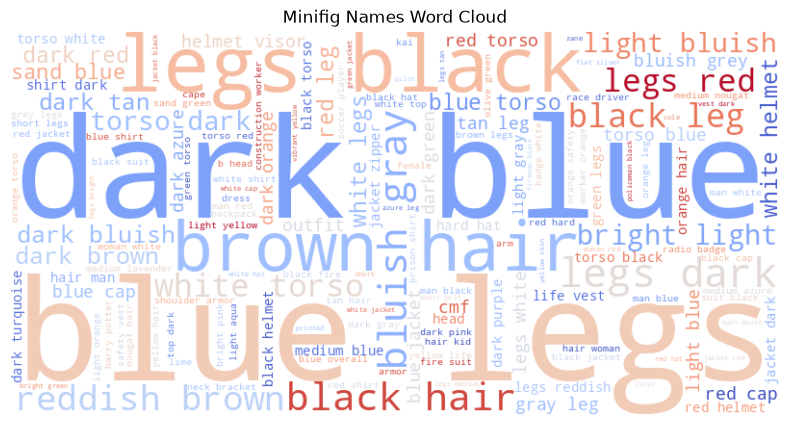

In [40]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

# Example: word cloud from minifig names
text = " ".join(minifigs["name"].astype(str).tolist())
text = re.sub(r"[^A-Za-z\s]", " ", text)
text = text.lower()

stopwords = set(STOPWORDS)
extra_stops = {"lego", "minifigure", "fig"}  # add domain-specific stopwords
stopwords |= extra_stops

text_clean = " ".join(
    word for word in text.split()
    if word not in stopwords
)

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=150,
    colormap="coolwarm"
).generate(text_clean)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Minifig Names Word Cloud")
plt.show()

In [41]:
keywords = ["football", "soccer", "stadium", "goalkeeper", "goal", "world cup"]

def contains_any(text: str, kws):
    t = text.lower()
    return any(k in t for k in kws)

# Soccer minifigs
soccer_minifigs = minifigs[minifigs["name"].apply(lambda x: contains_any(x, keywords))]
print(soccer_minifigs.head())

# Soccer sets
soccer_sets = sets[sets["name"].apply(lambda x: contains_any(x, keywords))]
print(soccer_sets.head())

        fig_num                                               name  num_parts  \
166  fig-000168  Soccer Player White Torso with Blue/Red Stripe...          4   
174  fig-000176                                      Soccer Player          4   
267  fig-000269               Soccer Player Coca-Cola Midfielder 1          4   
271  fig-000273                     Soccer Player Coca-Cola Goalie          4   
292  fig-000294  Soccer Player Goalie Blue Torso with Silver pr...          4   

                                               img_url  cluster  
166  https://cdn.rebrickable.com/media/sets/fig-000...        0  
174  https://cdn.rebrickable.com/media/sets/fig-000...        4  
267  https://cdn.rebrickable.com/media/sets/fig-000...        4  
271  https://cdn.rebrickable.com/media/sets/fig-000...        4  
292  https://cdn.rebrickable.com/media/sets/fig-000...        6  
      set_num                                     name  year  theme_id  \
486   10299-1  Real Madrid – Santiago Berna

In [43]:
sets = dfs["sets"].copy()
themes = dfs["themes"]

# join themes for context
sets = sets.merge(
    themes[["id", "name"]],
    left_on="theme_id",
    right_on="id",
    how="left",
    suffixes=("", "_theme")
)

def complexity_bucket(n):
    if n <= 50:
        return "Very Simple (<=50 parts)"
    if n <= 150:
        return "Simple (51–150 parts)"
    if n <= 500:
        return "Moderate (151–500 parts)"
    if n <= 1500:
        return "Complex (501–1500 parts)"
    return "Very Complex (>1500 parts)"

def age_proxy(name):
    name_l = name.lower()
    if any(k in name_l for k in ["duplo", "junior", "4+", "preschool"]):
        return "Younger Builders"
    if any(k in name_l for k in ["expert", "creator expert", "ucs", "collector"]):
        return "Advanced/Adult"
    return "General"

sets["complexity_bucket"] = sets["num_parts"].apply(complexity_bucket)
sets["age_proxy"] = sets["name"].apply(age_proxy)

sets_complexity = sets[
    ["set_num", "name", "year", "name_theme",
     "num_parts", "complexity_bucket", "age_proxy"]
]

sets_complexity.to_csv("sets_complexity_ageproxy.csv", index=False)

In [44]:
theme_complexity = (
    sets_complexity
    .groupby("name_theme")
    .agg(
        num_sets=("set_num", "nunique"),
        avg_parts=("num_parts", "mean"),
        max_parts=("num_parts", "max")
    )
    .reset_index()
)

theme_complexity.to_csv("theme_complexity_summary.csv", index=False)

In [48]:
import io
import zipfile
import requests
import pandas as pd

ZIP_URL = (
    "https://github.com/shannonlindsay/FabricCommunityContests/"
    "raw/main/StarterFiles/Round%202%20Source%20Files.zip"
)

def load_round2_data():
    resp = requests.get(ZIP_URL)
    resp.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(resp.content))

    dfs = {}
    dfs["colors"] = pd.read_csv(z.open("World Champs Round 2 Data/colors.csv"))
    dfs["inventories"] = pd.read_csv(z.open("World Champs Round 2 Data/inventories.csv"))
    dfs["inventory_minifigs"] = pd.read_csv(z.open("World Champs Round 2 Data/inventory_minifigs.csv"))
    dfs["inventory_parts"] = pd.read_csv(z.open("World Champs Round 2 Data/inventory_parts.csv"))
    dfs["inventory_sets"] = pd.read_csv(z.open("World Champs Round 2 Data/inventory_sets.csv"))
    dfs["minifigs"] = pd.read_csv(z.open("World Champs Round 2 Data/minifigs.csv"))
    dfs["parts"] = pd.read_csv(z.open("World Champs Round 2 Data/parts.csv"))
    dfs["part_categories"] = pd.read_csv(z.open("World Champs Round 2 Data/part_categories.csv"))
    dfs["sets"] = pd.read_csv(z.open("World Champs Round 2 Data/sets.csv"))
    dfs["themes"] = pd.read_csv(z.open("World Champs Round 2 Data/themes.csv"))
    return dfs

In [50]:
import pandas as pd

sets = dfs["sets"]
themes = dfs["themes"]

# join themes onto sets
sets_themes = sets.merge(
    themes,
    left_on="theme_id",
    right_on="id",
    how="left",
    suffixes=("_set", "_theme")
)

def infer_age_group(name_set: str, name_theme: str) -> str:
    text = f"{name_set} {name_theme}".lower()

    # very rough rules; meant for storytelling, not ground truth
    if any(k in text for k in ["duplo", "quatro", "primo", "junior", "4+", "easy to build"]):
        return "Early Builders (4–6)"
    if any(k in text for k in ["friends", "city", "creator", "bricks", "classic"]):
        return "Core Kids (6–12)"
    if any(k in text for k in ["technic", "expert", "architecture", "ucs", "collector"]):
        return "Advanced / Adult"
    if any(k in text for k in ["key chain", "keychain"]):
        return "Accessory"
    return "Unspecified"

sets_themes["age_group_heuristic"] = sets_themes.apply(
    lambda row: infer_age_group(row["name_set"], row["name_theme"]),
    axis=1
)

set_complexity_age = sets_themes[
    ["set_num", "name_set", "year", "theme_id", "name_theme", "num_parts", "age_group_heuristic"]
].rename(columns={"name_set": "set_name", "name_theme": "theme_name"})

set_complexity_age.to_csv("set_complexity_age.csv", index=False)

In [51]:

minifigs = dfs["minifigs"]

def infer_age_group_fig(name: str) -> str:
    name_l = name.lower()
    if any(k in name_l for k in ["kid", "child", "boy", "girl", "baby", "young"]):
        return "Child-coded"
    if any(k in name_l for k in ["grandfather", "grandmother", "grandpa", "grandma", "elder"]):
        return "Older Adult-coded"
    if any(k in name_l for k in ["man", "woman", "lady", "gentleman"]):
        return "Adult-coded"
    return "Unspecified"

minifigs["age_group_heuristic"] = minifigs["name"].apply(infer_age_group_fig)

minifig_complexity_age = minifigs[
    ["fig_num", "name", "num_parts", "age_group_heuristic"]
].rename(columns={"name": "fig_name"})

minifig_complexity_age.to_csv("minifig_complexity_age.csv", index=False)

In [53]:

inv_parts = dfs["inventory_parts"]
inventories = dfs["inventories"]
sets = dfs["sets"]
themes = dfs["themes"]
colors = dfs["colors"]

# 2. Link inventory_parts -> inventories -> sets
inv_parts_sets = inv_parts.merge(
    inventories[["id", "set_num"]],
    left_on="inventory_id",
    right_on="id",
    how="left",
)

inv_parts_sets = inv_parts_sets.merge(
    sets[["set_num", "year", "theme_id", "num_parts", "name"]],
    on="set_num",
    how="left",
)

inv_parts_sets = inv_parts_sets.merge(
    themes[["id", "name"]],
    left_on="theme_id",
    right_on="id",
    how="left",
    suffixes=("_set", "_theme"),
)

# 3. Merge colors and explicitly rename its name column
inv_parts_sets = inv_parts_sets.merge(
    colors[["id", "name"]],
    left_on="color_id",
    right_on="id",
    how="left",
)

# After this merge, we have a second 'name' column from colors; rename it:
inv_parts_sets = inv_parts_sets.rename(columns={
    "name_set": "set_name",
    "name_theme": "theme_name",
    "name": "color_name"  # this is the colors.name
})

# 4. Distinct colors per set
set_colors = (
    inv_parts_sets
    .groupby(["set_num", "year", "set_name", "theme_id", "theme_name"], dropna=False)["color_name"]
    .nunique()
    .reset_index()
    .rename(columns={"color_name": "num_distinct_colors"})
)

# 5. Add num_parts from sets (if needed; already present above but harmless to re-merge)
set_colors = set_colors.merge(
    sets[["set_num", "num_parts"]],
    on="set_num",
    how="left"
)

set_color_complexity = set_colors[
    ["set_num", "set_name", "year", "theme_id", "theme_name", "num_parts", "num_distinct_colors"]
]

set_color_complexity.to_csv("set_color_complexity.csv", index=False)
print(set_color_complexity.head())

        set_num                     set_name    year  theme_id  \
0  0003977811-1  Ninjago: Book of Adventures  2022.0     761.0   
1         001-1                        Gears  1965.0     756.0   
2        0012-1           Space Mini-Figures  1979.0     143.0   
3        0013-1           Space Mini-Figures  1979.0     143.0   
4        0014-1           Space Mini-Figures  1982.0     143.0   

                       theme_name  num_parts  num_distinct_colors  
0  Activity Books with LEGO Parts        1.0                    1  
1                       Samsonite       43.0                    5  
2                    Supplemental       12.0                    1  
3                    Supplemental       12.0                    1  
4                    Supplemental        2.0                    1  


In [54]:

inv_minifigs = dfs["inventory_minifigs"]
inv_parts = dfs["inventory_parts"]
colors = dfs["colors"]
minifigs = dfs["minifigs"]

# link minifigs to inventory_parts and colors
minifig_inv_parts = (
    inv_minifigs[["inventory_id", "fig_num"]]
    .merge(inv_parts[["inventory_id", "color_id"]], on="inventory_id", how="left")
    .merge(colors[["id", "name"]], left_on="color_id", right_on="id", how="left")
)

# distinct colors per minifig
minifig_color_counts = (
    minifig_inv_parts
    .groupby("fig_num")["name"]
    .nunique()
    .reset_index()
    .rename(columns={"name": "num_distinct_colors"})
)

# add fig metadata
minifig_color_complexity = minifig_color_counts.merge(
    minifigs[["fig_num", "name", "num_parts"]],
    on="fig_num",
    how="left"
).rename(columns={"name": "fig_name"})

minifig_color_complexity.to_csv("minifig_color_complexity.csv", index=False)

count    27069.000000
mean       168.062839
std        443.058812
min          0.000000
25%          0.000000
50%         26.000000
75%        140.000000
max      11695.000000
Name: num_parts, dtype: float64


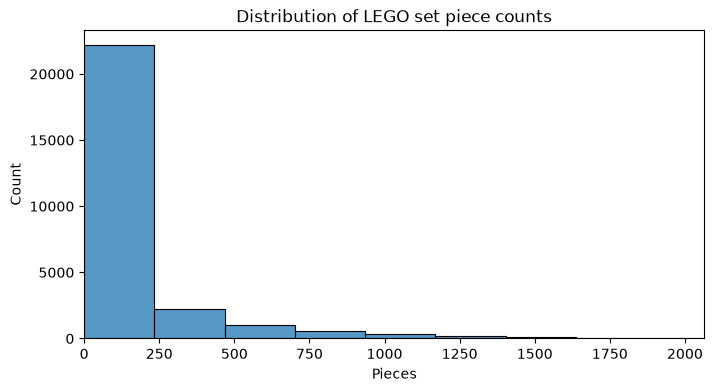

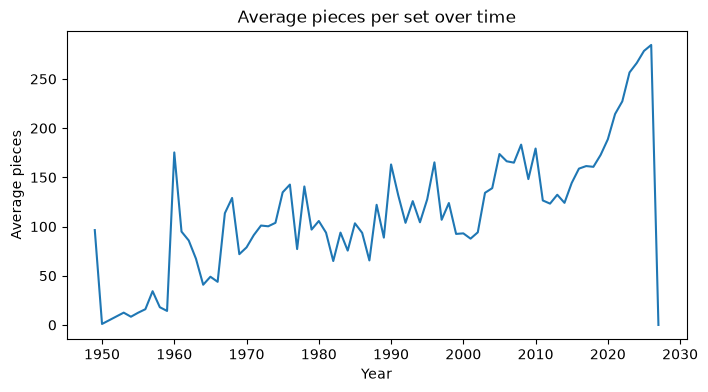

In [55]:

sets = dfs["sets"]
themes = dfs["themes"]

sets_themes = sets.merge(
    themes,
    left_on="theme_id",
    right_on="id",
    how="left",
    suffixes=("_set", "_theme")
)

# basic stats
print(sets["num_parts"].describe())

# distribution of pieces
plt.figure(figsize=(8, 4))
sns.histplot(sets["num_parts"], bins=50)
plt.xlim(0, sets["num_parts"].quantile(0.99))
plt.title("Distribution of LEGO set piece counts")
plt.xlabel("Pieces")
plt.ylabel("Count")
plt.show()

# average pieces per year
avg_pieces_year = (
    sets.groupby("year")["num_parts"]
    .mean()
    .reset_index()
    .rename(columns={"num_parts": "avg_num_parts"})
)

plt.figure(figsize=(8, 4))
sns.lineplot(data=avg_pieces_year, x="year", y="avg_num_parts")
plt.title("Average pieces per set over time")
plt.xlabel("Year")
plt.ylabel("Average pieces")
plt.show()

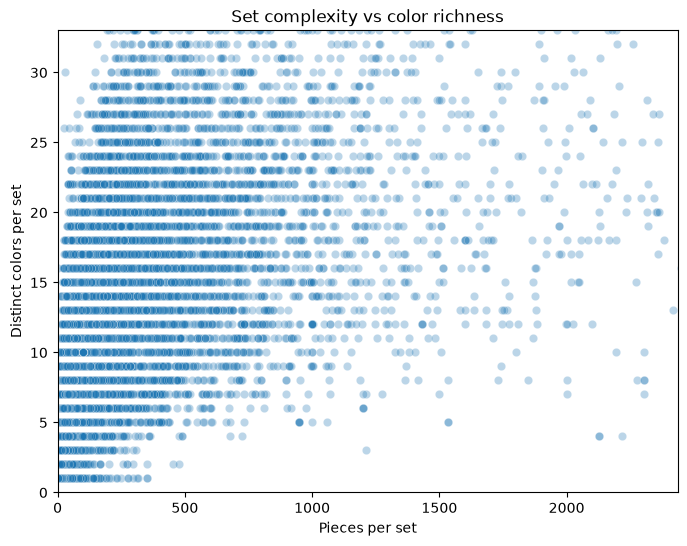

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

inv_parts = dfs["inventory_parts"]
inventories = dfs["inventories"]
sets = dfs["sets"]
themes = dfs["themes"]
colors = dfs["colors"]

inv_parts_sets = inv_parts.merge(
    inventories[["id", "set_num"]],
    left_on="inventory_id",
    right_on="id",
    how="left",
)
inv_parts_sets = inv_parts_sets.merge(
    sets[["set_num", "year", "theme_id", "num_parts", "name"]],
    on="set_num",
    how="left",
)
inv_parts_sets = inv_parts_sets.merge(
    themes[["id", "name"]],
    left_on="theme_id",
    right_on="id",
    how="left",
    suffixes=("_set", "_theme"),
)
inv_parts_sets = inv_parts_sets.merge(
    colors[["id", "name"]],
    left_on="color_id",
    right_on="id",
    how="left",
)
inv_parts_sets = inv_parts_sets.rename(columns={
    "name_set": "set_name",
    "name_theme": "theme_name",
    "name": "color_name",
})

set_colors = (
    inv_parts_sets
    .groupby(["set_num", "year", "set_name", "theme_name"], dropna=False)["color_name"]
    .nunique()
    .reset_index()
    .rename(columns={"color_name": "num_distinct_colors"})
)

set_colors = set_colors.merge(
    sets[["set_num", "num_parts"]],
    on="set_num",
    how="left"
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=set_colors,
    x="num_parts",
    y="num_distinct_colors",
    alpha=0.3
)
plt.xlim(0, set_colors["num_parts"].quantile(0.99))
plt.ylim(0, set_colors["num_distinct_colors"].quantile(0.99))
plt.xlabel("Pieces per set")
plt.ylabel("Distinct colors per set")
plt.title("Set complexity vs color richness")
plt.show()

count    16960.000000
mean         5.285613
std          6.087053
min          0.000000
25%          4.000000
50%          4.000000
75%          5.000000
max        156.000000
Name: num_parts, dtype: float64


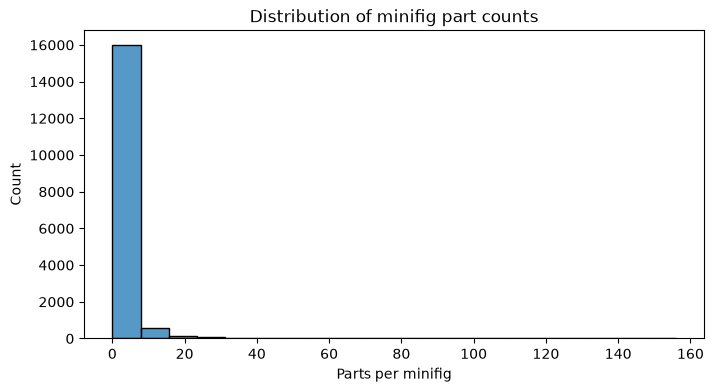

In [57]:

minifigs = dfs["minifigs"]

print(minifigs["num_parts"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(minifigs["num_parts"], bins=20)
plt.title("Distribution of minifig part counts")
plt.xlabel("Parts per minifig")
plt.ylabel("Count")
plt.show()

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# assume set_color_complexity has already been built as before
# with columns: set_num, set_name, num_parts, num_distinct_colors, ...

set_colors = set_color_complexity.copy()

# 1. Filter to rows with non-null features
mask = set_colors[["num_parts", "num_distinct_colors"]].notnull().all(axis=1)
set_colors_clean = set_colors.loc[mask].reset_index(drop=True)

features = set_colors_clean[["num_parts", "num_distinct_colors"]].values

# 2. Scale and cluster
scaler = StandardScaler()
X = scaler.fit_transform(features)

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X)

# 3. Assign clusters to the CLEAN DataFrame only
set_colors_clean["complexity_cluster"] = clusters

print(set_colors_clean[["set_num", "set_name", "num_parts", "num_distinct_colors", "complexity_cluster"]].head())

# 4. (Optional) merge back to the full set_colors if you want cluster labels there too
set_colors_with_clusters = set_colors.merge(
    set_colors_clean[["set_num", "complexity_cluster"]],
    on="set_num",
    how="left"
)

set_colors_with_clusters.to_csv("set_color_complexity_clusters.csv", index=False)

        set_num                     set_name  num_parts  num_distinct_colors  \
0  0003977811-1  Ninjago: Book of Adventures        1.0                    1   
1         001-1                        Gears       43.0                    5   
2        0012-1           Space Mini-Figures       12.0                    1   
3        0013-1           Space Mini-Figures       12.0                    1   
4        0014-1           Space Mini-Figures        2.0                    1   

   complexity_cluster  
0                   3  
1                   3  
2                   3  
3                   3  
4                   3  


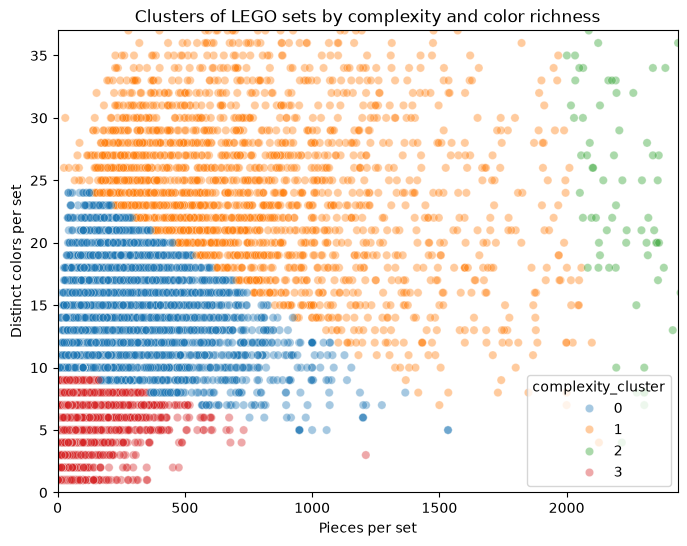

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=set_colors_clean,
    x="num_parts",
    y="num_distinct_colors",
    hue="complexity_cluster",
    palette="tab10",
    alpha=0.4
)
plt.xlim(0, set_colors_clean["num_parts"].quantile(0.99))
plt.ylim(0, set_colors_clean["num_distinct_colors"].quantile(0.99))
plt.xlabel("Pieces per set")
plt.ylabel("Distinct colors per set")
plt.title("Clusters of LEGO sets by complexity and color richness")
plt.show()

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

minifigs = dfs["minifigs"].copy()
texts = minifigs["name"].astype(str).values

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=5
)
X = vectorizer.fit_transform(texts)

k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X)

minifigs["name_cluster"] = clusters

terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"\nCluster {i} top terms: {top_terms}")

print(minifigs[["fig_num", "name", "name_cluster"]].head())


Cluster 0 top terms: ['torso', 'legs', 'white', 'blue', 'black', 'red', 'hair', 'brown', 'cap', 'dark']

Cluster 1 top terms: ['pants', 'blue', 'dark', 'sand', 'shirt', 'white', 'turquoise', 'bright', 'black', 'leo']

Cluster 2 top terms: ['skirt', 'dark', 'magenta', 'stephanie', 'light', 'andrea', 'bright', 'olivia', 'pink', 'medium']

Cluster 3 top terms: ['black', 'red', 'blue', 'white', 'jacket', 'legs', 'helmet', 'man', 'cap', 'hat']

Cluster 4 top terms: ['cmf', 'armor', 'outfit', 'black', 'dark', 'green', 'helmet', 'white', 'head', 'droid']

Cluster 5 top terms: ['mia', 'skirt', 'lime', 'purple', 'dark', 'trousers', 'olive', 'green', 'blue', 'medium']

Cluster 6 top terms: ['dark', 'blue', 'legs', 'hair', 'bluish', 'brown', 'torso', 'tan', 'gray', 'light']

Cluster 7 top terms: ['santa', 'plain', 'red', 'hat', 'claus', 'head', 'legs', 'boots', 'hips', 'black']
      fig_num                                      name  name_cluster
0  fig-000001                        Toy Store Em

                     theme_name  avg_num_parts  avg_num_colors  num_sets
185                    LEGO Art    2762.840000       16.400000        25
225           Modular Buildings    2637.571429       31.523810        21
143                Ghostbusters    2599.000000       32.500000         2
385   Ultimate Collector Series    2542.940000       18.160000        50
383                         UCS    2437.500000       18.666667         6
43   BrickLink Designer Program    2114.913793       31.482759        58
163                       Icons    2114.762500       23.187500        80
230                      Mosaic    2100.571429        7.142857         7
281                  Sculptures    2089.000000        6.333333         3
256                     Pokémon    2004.000000       27.200000         5
312                Serious Play    1826.600000       20.200000        20
364         The Legend of Zelda    1751.500000       35.500000         2
75               Creator Expert    1742.521739     

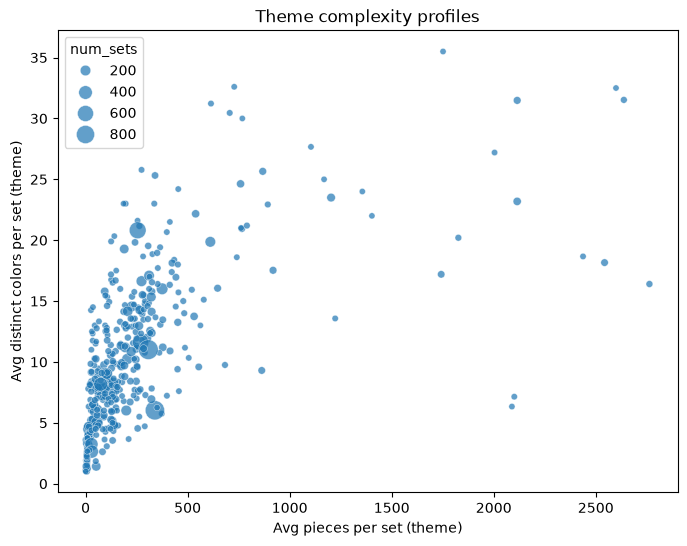

In [62]:
theme_profiles = (
    set_colors
    .groupby("theme_name")
    .agg(
        avg_num_parts=("num_parts", "mean"),
        avg_num_colors=("num_distinct_colors", "mean"),
        num_sets=("set_num", "nunique")
    )
    .reset_index()
)

print(theme_profiles.sort_values("avg_num_parts", ascending=False).head(20))

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=theme_profiles,
    x="avg_num_parts",
    y="avg_num_colors",
    size="num_sets",
    sizes=(20, 200),
    alpha=0.7
)
plt.xlabel("Avg pieces per set (theme)")
plt.ylabel("Avg distinct colors per set (theme)")
plt.title("Theme complexity profiles")
plt.show()

In [63]:

inv_parts = dfs["inventory_parts"]
inventories = dfs["inventories"]
sets = dfs["sets"]
themes = dfs["themes"]
colors = dfs["colors"]

# Link inventory_parts -> inventories -> sets -> colors
inv_parts_sets = inv_parts.merge(
    inventories[["id", "set_num"]],
    left_on="inventory_id",
    right_on="id",
    how="left",
)

inv_parts_sets = inv_parts_sets.merge(
    sets[["set_num", "year"]],
    on="set_num",
    how="left",
)

inv_parts_sets = inv_parts_sets.merge(
    colors[["id", "name", "rgb"]],
    left_on="color_id",
    right_on="id",
    how="left",
)

inv_parts_sets = inv_parts_sets.rename(columns={"name": "color_name"})

# Total quantity per year & color
color_year_qty = (
    inv_parts_sets
    .groupby(["year", "color_name", "rgb"], dropna=False)["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"quantity": "total_quantity"})
)

# For each year, pick the max color
idx = (
    color_year_qty
    .groupby("year")["total_quantity"]
    .idxmax()
    .dropna()
)

most_common_color_year = color_year_qty.loc[idx].sort_values("year")
print(most_common_color_year.head())

most_common_color_year.to_csv("most_common_color_by_year.csv", index=False)

      year color_name     rgb  total_quantity
8   1949.0      White  FFFFFF             199
10  1950.0       Blue  0055BF              10
14  1953.0      Green  237841              26
21  1954.0        Red  C91A09              70
29  1955.0      White  FFFFFF             488


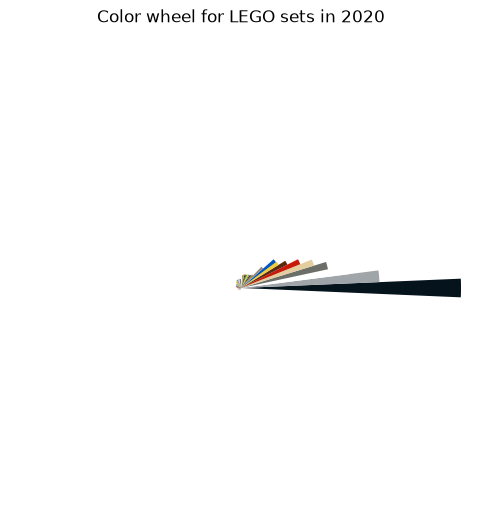

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Use color_year_qty from above, plus per-year totals
year_totals = (
    color_year_qty
    .groupby("year")["total_quantity"]
    .sum()
    .reset_index()
    .rename(columns={"total_quantity": "year_total"})
)

color_year_share = color_year_qty.merge(year_totals, on="year")
color_year_share["share"] = (
    color_year_share["total_quantity"] / color_year_share["year_total"]
)

# Example: color wheel for a single year, e.g., 2020
year_example = 2020
df_year = color_year_share[color_year_share["year"] == year_example].copy()

# Sort by share to get a stable ordering
df_year = df_year.sort_values("share", ascending=False).reset_index(drop=True)

angles = np.linspace(0, 2 * np.pi, len(df_year), endpoint=False)
sizes = df_year["share"].values

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)

for angle, size, rgb_hex in zip(angles, sizes, df_year["rgb"]):
    # convert hex to matplotlib color
    rgb = tuple(int(rgb_hex[i:i+2], 16)/255 for i in (0, 2, 4))
    ax.bar(angle, size, width=2*np.pi/len(df_year), color=rgb, edgecolor="none")

ax.set_title(f"Color wheel for LEGO sets in {year_example}")
ax.set_axis_off()
plt.show()

In [73]:

inventories = pd.read_csv(z.open("World Champs Round 2 Data/inventories.csv"))
inventory_parts = pd.read_csv(z.open("World Champs Round 2 Data/inventory_parts.csv"))
sets = pd.read_csv(z.open("World Champs Round 2 Data/sets.csv"))
colors = pd.read_csv(z.open("World Champs Round 2 Data/colors.csv"))

# link parts -> inventories -> sets -> colors
inv_parts_sets = inventory_parts.merge(
    inventories[["id", "set_num"]],
    left_on="inventory_id",
    right_on="id",
    how="left",
)

inv_parts_sets = inv_parts_sets.merge(
    sets[["set_num", "year"]],
    on="set_num",
    how="left",
)

inv_parts_sets = inv_parts_sets.merge(
    colors[["id", "name", "rgb"]],
    left_on="color_id",
    right_on="id",
    how="left",
)

inv_parts_sets = inv_parts_sets.rename(columns={"name": "color_name"})

# quantity per year & color
color_year_qty = (
    inv_parts_sets
    .groupby(["year", "color_name", "rgb"], dropna=False)["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"quantity": "total_quantity"})
)

# per-year totals and share (0–1, i.e., 0–100%)
year_totals = (
    color_year_qty
    .groupby("year")["total_quantity"]
    .sum()
    .reset_index()
    .rename(columns={"total_quantity": "year_total"})
)

color_year_share = color_year_qty.merge(year_totals, on="year")
color_year_share["share"] = color_year_share["total_quantity"] / color_year_share["year_total"]

color_year_share.to_csv("color_year_share.csv", index=False)

In [74]:
import plotly.express as px

# ensure years are sorted and reasonable
color_year_share_clean = color_year_share.dropna(subset=["year", "color_name"])

fig = px.bar(
    color_year_share_clean,
    x="color_name",
    y="share",
    color="color_name",
    animation_frame="year",
    title="LEGO color share by year",
    labels={"share": "Color share (0–1)", "color_name": "Color"}
)

fig.update_layout(
    xaxis={'categoryorder': 'total descending'},
    yaxis={'range': [0, 1]}
)

fig.show()

In [75]:
color_year_share_clean["decade"] = (color_year_share_clean["year"] // 10) * 10

fig_decade = px.bar(
    color_year_share_clean,
    x="color_name",
    y="share",
    color="color_name",
    animation_frame="decade",
    title="LEGO color share by decade",
)
fig_decade.update_layout(yaxis={'range': [0, 1]})
fig_decade.show()

In [76]:
# most common color per year
idx_max = (
    color_year_share
    .groupby("year")["total_quantity"]
    .idxmax()
    .dropna()
)
most_common_color_year = color_year_share.loc[idx_max].copy()

# least common (among colors present that year)
idx_min = (
    color_year_share
    .groupby("year")["total_quantity"]
    .idxmin()
    .dropna()
)
least_common_color_year = color_year_share.loc[idx_min].copy()

# line chart of quantity or share for top/bottom colors
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=most_common_color_year["year"],
    y=most_common_color_year["share"],
    mode="lines+markers",
    name="Most common color (share)",
    text=most_common_color_year["color_name"],
    hovertemplate="Year %{x}<br>Color %{text}<br>Share %{y:.2f}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=least_common_color_year["year"],
    y=least_common_color_year["share"],
    mode="lines+markers",
    name="Least common color (share)",
    text=least_common_color_year["color_name"],
    hovertemplate="Year %{x}<br>Color %{text}<br>Share %{y:.4f}<extra></extra>"
))

fig.update_layout(
    title="Most and least common LEGO colors over time",
    xaxis_title="Year",
    yaxis_title="Share of parts (0–1)"
)

fig.show()

In [79]:
%pip install ipympl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 33.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ipympl]2m2/4 [ipywidgets]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [81]:
# Activate the interactive backend
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

# Generate data
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

# Create and display the interactive plot
fig, ax = plt.subplots()
ax.plot(x, y)
ax.grid(True)
plt.show()


RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [82]:
# most common color per year (unchanged)
idx_max = (
    color_year_share
    .groupby("year")["total_quantity"]
    .idxmax()
    .dropna()
)
most_common_color_year = color_year_share.loc[idx_max].copy()

# least common among colors that actually appear that year (total_quantity > 0)
color_year_nonzero = color_year_share[color_year_share["total_quantity"] > 0]

idx_min = (
    color_year_nonzero
    .groupby("year")["total_quantity"]
    .idxmin()
    .dropna()
)
least_common_color_year = color_year_nonzero.loc[idx_min].copy()

# line chart of quantity or share for top/bottom colors
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=most_common_color_year["year"],
    y=most_common_color_year["share"],
    mode="lines+markers",
    name="Most common color (share)",
    text=most_common_color_year["color_name"],
    hovertemplate="Year %{x}<br>Color %{text}<br>Share %{y:.2f}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=least_common_color_year["year"],
    y=least_common_color_year["share"],
    mode="lines+markers",
    name="Least common color (share, >0)",
    text=least_common_color_year["color_name"],
    hovertemplate="Year %{x}<br>Color %{text}<br>Share %{y:.4f}<extra></extra>"
))

fig.update_layout(
    title="Most and least common LEGO colors over time (non-zero least)",
    xaxis_title="Year",
    yaxis_title="Share of parts (0–1)"
)

fig.show()